<a href="https://colab.research.google.com/github/gre1wy/Machine_Learning/blob/main/lab6/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **YOLOv12: Attention-Centric Real-Time Object Detectors**

https://doi.org/10.48550/arXiv.2502.12524  
https://github.com/sunsmarterjie/yolov12


Стаття присвячена завданню виявлення об'єктів у реальному часі (Real-Time Object Detection). Основна мета — розробити фреймворк, який значно підвищує точність (mAP) порівняно з попередніми версіями YOLO та іншими детекторами (навіть Transformer-based, як-от RT-DETR), при цьому зберігаючи або навіть покращуючи швидкість інференсу (Latency).

Автори демонструють, що YOLOv12-N досягає 40.6% mAP на датасеті MS COCO, перевершуючи YOLOv11-N і YOLOv10-N, із конкурентною швидкістю.

## Алгоритм та Ідея (Новизна)

Новизна YOLOv12 полягає у створенні «Attention-Centric» (центрованої на увазі) архітектури, яка вперше у сімействі YOLO замінює традиційні архітектури, засновані виключно на CNN (Convolutional Neural Networks), на модель, що повноцінно використовує механізми уваги.

Ідея полягає в тому, щоб подолати основний недолік механізмів уваги (які ефективні для моделювання глобальних залежностей, але повільніші) та зробити їх придатними для роботи в реальному часі.

## Як це досягається
YOLOv12 досягає цього балансу за допомогою низки архітектурних інновацій:

FlashAttention для Областей (Area Attention): Замість того, щоб обчислювати увагу для всього зображення (що вимагає великого обсягу пам'яті та обчислень), YOLOv12 використовує механізм FlashAttention, адаптований для обробки певних областей (Area-based Attention). Це значно зменшує навантаження на пам'ять і прискорює інференс, зберігаючи при цьому переваги уваги.

R-ELAN (Residual Efficient Layer Aggregation Networks): Нова, оптимізована базова мережа (Backbone), яка покращує потік градієнтів та підвищує ефективність обчислень, роблячи модель стійкішою до оптимізації та легшою у масштабуванні.

Використання 7x7 Роздільних Згорток (Separable Convolutions): Застосування цих згорток додатково підвищує ефективність та зменшує кількість параметрів.

## Перевага над іншими алгоритмами
YOLOv12 краща за попередні алгоритми за ключовим показником: співвідношенням точності та швидкості (Latency-Accuracy Trade-off).

Над іншими YOLO (v8, v10, v11): Вона забезпечує вищу точність (mAP) при порівнянній або кращій швидкості, вперше успішно інтегрувавши потужні механізми уваги без втрати швидкості, характерної для попередніх CNN-based моделей.

Над Transformer-based детекторами (наприклад, RT-DETR): YOLOv12 демонструє кращі результати при меншій кількості обчислень та параметрів, оскільки її архітектура оптимізована саме для швидкості, на відміну від Transformer-based конкурентів, які часто повільніші, навіть якщо мають високу точність.

# Тест

In [1]:
!pip install ultralytics

In [2]:
!git clone https://github.com/sunsmarterjie/yolov12.git

fatal: destination path 'yolov12' already exists and is not an empty directory.


In [3]:
%cd yolov12

/content/yolov12


In [4]:
!wget https://github.com/Dao-AILab/flash-attention/releases/download/v2.7.3/flash_attn-2.7.3+cu11torch2.2cxx11abiFALSE-cp311-cp311-linux_x86_64.whl
!pip install flash_attn-2.7.3+cu11torch2.2cxx11abiFALSE-cp311-cp311-linux_x86_64.whl

!pip install -r requirements.txt
!pip install -e .

--2025-11-22 18:43:21--  https://github.com/Dao-AILab/flash-attention/releases/download/v2.7.3/flash_attn-2.7.3+cu11torch2.2cxx11abiFALSE-cp311-cp311-linux_x86_64.whl
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/494232964/b7fb7022-424c-4ac2-b46b-a41f386edaa5?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-11-22T19%3A18%3A08Z&rscd=attachment%3B+filename%3Dflash_attn-2.7.3%2Bcu11torch2.2cxx11abiFALSE-cp311-cp311-linux_x86_64.whl&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-11-22T18%3A17%3A54Z&ske=2025-11-22T19%3A18%3A08Z&sks=b&skv=2018-11-09&sig=uW6WMlZUMvWZmpG5vsg%2F9o4a2MM%2BlYJsGEymc2bhS6w%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcm

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/yolov12/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
FlashAttention is not available on this device. Using scaled_dot_product_attention instead.
--2025-11-22 18:44:13--  https://ultralytics.com/images/bus.jpg
Resolving ultralytics.com (ultralytics.com)... 198.202.211.1
Connecting to ultralytics.com (ultralytics.com)|198.202.211.1|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.ultralytics.com/images/bus.jpg [following]
--2025-11-22 18:44:13--  https://www.ultralytics.com/images/bus.jpg
Resolving www.ultralytics.com (www.ultralytics.com)... 198.202.211.1, 2620:cb:2000::1
Connecting to www.ultralytics.com (www.ultralytics.com)|198.202.211.1|:443... connected.
HTTP request sent, awaiti

100%|██████████| 5.26M/5.26M [00:00<00:00, 109MB/s]



image 1/1 /content/yolov12/test_image.jpg: 640x480 4 persons, 1 bus, 56.1ms
Speed: 2.6ms preprocess, 56.1ms inference, 80.3ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/yolov12/runs/detect/predict
Результат збережено в: /content/yolov12/runs/detect/predict


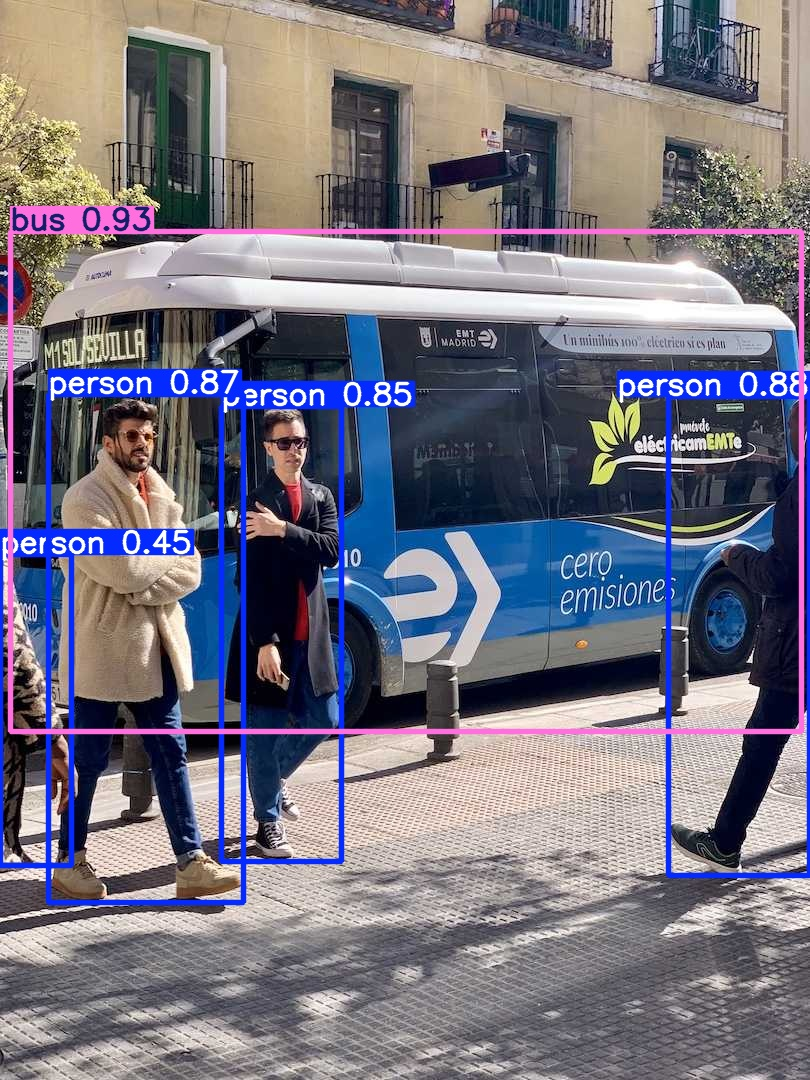

In [5]:
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import cv2
import os

!wget -O test_image.jpg https://ultralytics.com/images/bus.jpg

model = YOLO('yolov12n.pt')

results = model.predict(source='test_image.jpg', save=True, conf=0.25)

result_image_path = os.path.join(results[0].save_dir, 'test_image.jpg')
print("Результат збережено в:", results[0].save_dir)

if os.path.exists(result_image_path):
    processed_image = cv2.imread(result_image_path)
    cv2_imshow(processed_image)
else:
    print("Помилка")

In [12]:
from google.colab import files
import os

uploaded = files.upload()

if uploaded:
    MY_FILE_NAME = list(uploaded.keys())[0]
    print(f"Файл '{MY_FILE_NAME}' успішно завантажено.")
else:
    MY_FILE_NAME = "default_image.jpg"

Saving test.jpg to test (2).jpg
Файл 'test (2).jpg' успішно завантажено.



image 1/1 /content/yolov12/test (2).jpg: 384x640 10 persons, 16.0ms
Speed: 2.1ms preprocess, 16.0ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/yolov12/runs/detect/predict4
Результат збережено в: /content/yolov12/runs/detect/predict4


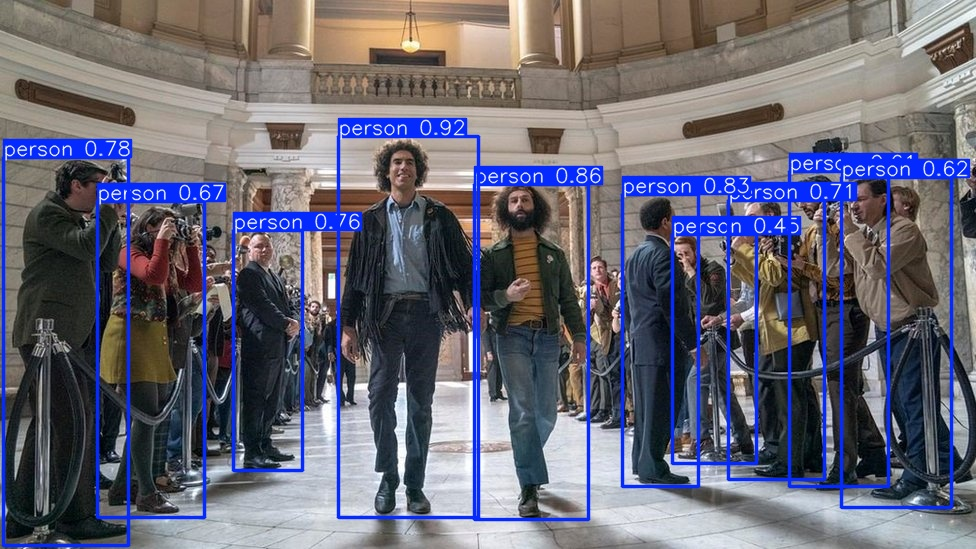

In [13]:
source_file = MY_FILE_NAME

model = YOLO('yolov12n.pt')

results = model.predict(source=source_file, save=True, conf=0.25)

result_image_path = os.path.join(results[0].save_dir, source_file)
print("Результат збережено в:", results[0].save_dir)

if os.path.exists(result_image_path):
    processed_image = cv2.imread(result_image_path)
    cv2_imshow(processed_image)
else:
    print("Помилка")